### **Project Name**    - Amazon Prime Movies & TV Shows Analysis

##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Updesh Chuahan


# **Project Summary -**

This project focuses on performing Exploratory Data Analysis (EDA) on Amazon Prime’s movies and TV shows dataset to extract meaningful insights about content trends, genres, ratings, production patterns, and audience preferences. The dataset consists of two main files: titles.csv, which contains information about movies and shows (title, genre, release year, rating, runtime, etc.), and credits.csv, which includes cast and crew details.

The first step involved merging both datasets using a common key (id) to create a unified dataset. This allowed a deeper analysis by connecting content attributes with cast and crew information. Data cleaning was performed by handling missing values, removing duplicates, and converting data types where necessary. Columns like genres and cast were processed for better usability.

Univariate analysis was conducted to understand distributions of variables such as release year, content type (movie vs show), and ratings. It was observed that movies dominate the platform compared to TV shows. Additionally, a surge in content production was noticed after 2010, indicating rapid expansion of the streaming platform.

Bivariate analysis helped uncover relationships between variables. For example, comparing genres with ratings revealed that drama and comedy genres are the most popular. Analysis between release year and content count showed a consistent increase in production over time. Further, examining runtime vs ratings helped identify that moderately long content tends to perform better.

Multivariate analysis, including correlation heatmaps and pair plots, revealed that there are weak correlations between numerical variables like runtime and rating, suggesting that audience preferences depend more on qualitative aspects such as genre and cast rather than duration.

Insights derived from this analysis can help Amazon Prime optimize its content strategy. For example, investing more in high-performing genres, focusing on popular actors, and maintaining optimal content length can improve user engagement. Additionally, identifying underperforming genres can help avoid unnecessary investments.

Overall, this project demonstrates how data-driven insights can support strategic decisions in the streaming industry.

# **GitHub Link -**

https://github.com/updesh1

# **Problem Statement**


Analyze Amazon Prime content data to identify trends, patterns, and factors influencing content popularity.

#### **Define Your Business Objective?**

- Understand user content preferences
- Identify top-performing genres and content types
- Optimize content production strategy
- Improve viewer engagement

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [284]:
# Import Libraries
import pandas as pd

titles = pd.read_csv('titles.csv')
credits = pd.read_csv('credits.csv')

### Dataset Loading

In [285]:
# Load Dataset
df = pd.merge(titles, credits, on='id', how='left')

### Dataset First View

In [286]:
# Dataset First Look
df.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,59401.0,Joe Besser,Joe,ACTOR
1,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31460.0,Moe Howard,Moe,ACTOR
2,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31461.0,Larry Fine,Larry,ACTOR
3,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,21174.0,Buster Keaton,Johnny Gray,ACTOR
4,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,28713.0,Marion Mack,Annabelle Lee,ACTOR


### Dataset Rows & Columns count

In [287]:
# Dataset Rows & Columns count
df.shape

(125354, 19)

### Dataset Information

In [288]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125354 entries, 0 to 125353
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    125354 non-null  object 
 1   title                 125354 non-null  object 
 2   type                  125354 non-null  object 
 3   description           125163 non-null  object 
 4   release_year          125354 non-null  int64  
 5   age_certification     56857 non-null   object 
 6   runtime               125354 non-null  int64  
 7   genres                125354 non-null  object 
 8   production_countries  125354 non-null  object 
 9   seasons               8501 non-null    float64
 10  imdb_id               119978 non-null  object 
 11  imdb_score            118987 non-null  float64
 12  imdb_votes            118957 non-null  float64
 13  tmdb_popularity       124800 non-null  float64
 14  tmdb_score            114263 non-null  float64
 15  

#### Duplicate Values

In [289]:
# Dataset Duplicate Value Count
df.duplicated().sum()

168

#### Missing Values/Null Values

In [290]:
# Missing Values/Null Values Count
df.isnull().sum()

id                           0
title                        0
type                         0
description                191
release_year                 0
age_certification        68497
runtime                      0
genres                       0
production_countries         0
seasons                 116853
imdb_id                   5376
imdb_score                6367
imdb_votes                6397
tmdb_popularity            554
tmdb_score               11091
person_id                 1007
name                      1007
character                17314
role                      1007
dtype: int64

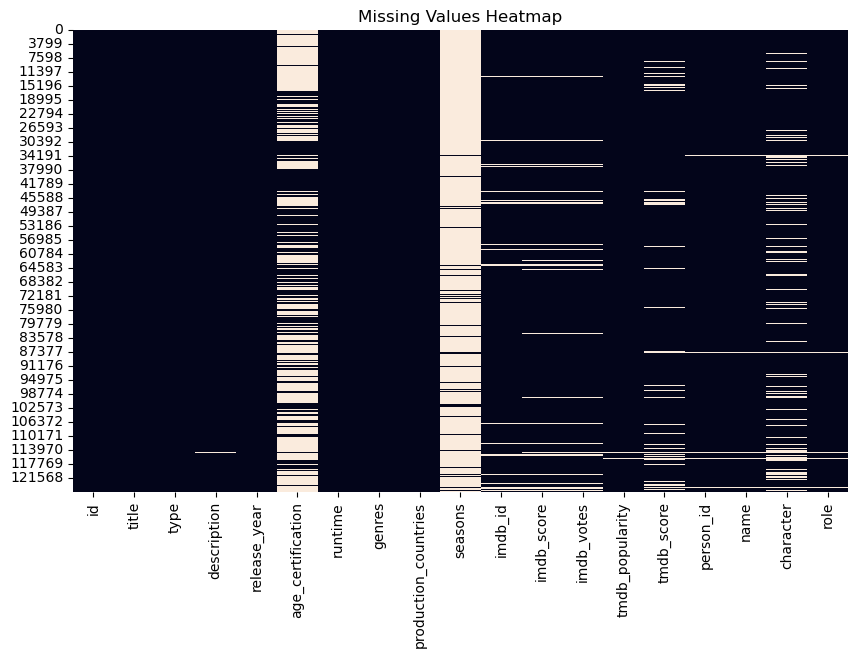

In [291]:
# Visualizing the missing values
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

### What did you know about your dataset?

From the initial exploration of the dataset, the following key observations were made:

- The dataset is a combination of Amazon Prime titles and credits data, providing detailed information about movies and TV shows along with cast and crew details.

- It contains both categorical variables (such as title, type, genres, cast) and numerical variables (such as release_year, runtime, rating).

- After merging the datasets, the number of rows increased because a single title can have multiple cast/crew entries, resulting in repeated titles with different associated people.

- The dataset includes missing values in certain columns like cast, director, or rating, which need to be handled during data preprocessing.

- Some duplicate records may be present due to merging or data redundancy, which should be removed to ensure data quality.

- The dataset shows a wide range of content across different years, genres, and types (movies vs TV shows), making it suitable for trend analysis.

- Data types are mixed and may require conversion or transformation for proper analysis.

## ***2. Understanding Your Variables***

In [292]:
# Dataset Columns
df.columns

Index(['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity',
       'tmdb_score', 'person_id', 'name', 'character', 'role'],
      dtype='object')

In [293]:
# Dataset Describe
df.describe()

,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id
count,125354.000000,125354.00000,8501.000000,118987.000000,1.189570e+05,124800.000000,114263.000000,1.243470e+05
mean,1996.374715,95.30792,2.335372,5.970856,2.311206e+04,10.134483,5.993077,4.062528e+05
std,27.758800,30.39349,3.164860,1.243967,8.816389e+04,40.666765,1.322900,5.614483e+05
min,1912.000000,1.00000,1.000000,1.100000,5.000000e+00,0.000011,0.800000,1.000000e+00
25%,1983.000000,82.00000,1.000000,5.200000,2.790000e+02,1.858000,5.300000,3.899600e+04
50%,2009.000000,93.00000,1.000000,6.100000,1.227000e+03,3.864000,6.100000,1.339340e+05
75%,2017.000000,109.00000,2.000000,6.800000,7.039000e+03,8.787000,6.800000,5.711600e+05
max,2022.000000,549.00000,51.000000,9.900000,1.133692e+06,1437.906000,10.000000,2.371153e+06


### Variables Description

Below is the description of each variable present in the dataset:

- id → Unique identifier assigned to each movie or TV show
- title → Name of the content available on Amazon Prime
- type → Specifies whether the content is a Movie or a TV Show
- description → Brief summary or storyline of the content
- release_year → The year in which the content was released
- age_certification → Indicates the suitable audience category (e.g., PG, R, 13+)
- runtime → Duration of the movie/show in minutes
- genres → Category or type of content (e.g., Drama, Comedy, Action)
- production_countries → Country or countries where the content was produced
- imdb_score → Rating given to the content on IMDb (scale typically 0–10)
- imdb_votes → Total number of votes received on IMDb
- cast → List of actors/actresses involved in the content
- director → Director(s) of the movie or show

### Check Unique Values for each variable.

In [294]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"Column: {col}")
    print(df[col].nunique())
    print(df[col].unique()[:5])  # show first 5 unique values
    print("-"*50)

Column: id
9868
['ts20945' 'tm19248' 'tm82253' 'tm83884' 'tm56584']
--------------------------------------------------
Column: title
9737
['The Three Stooges' 'The General' 'The Best Years of Our Lives'
 'His Girl Friday' 'In a Lonely Place']
--------------------------------------------------
Column: type
2
['SHOW' 'MOVIE']
--------------------------------------------------
Column: description
9734
["The Three Stooges were an American vaudeville and comedy team active from 1922 until 1970, best known for their 190 short subject films by Columbia Pictures that have been regularly airing on television since 1958. Their hallmark was physical farce and slapstick. In films, the stooges were commonly known by their actual first names. There were a total of six stooges over the act's run (with only three active at any given time), but Moe Howard and Larry Fine were the mainstays throughout the ensemble's nearly fifty-year run."
 "During America’s Civil War, Union spies steal engineer Johnnie 

## 3. ***Data Wrangling***

### Data Wrangling Code

In [295]:
# Write your code to make your dataset analysis ready.

# 1. Remove duplicates
df = df.drop_duplicates()

# 2. Handle missing values
df.fillna({
    'imdb_score': df['imdb_score'].mean(),
    'runtime': df['runtime'].median(),
    'genres': 'Unknown',
    'cast': 'Unknown'
}, inplace=True)

# 3. Fix data types
df['release_year'] = df['release_year'].astype(int)

# 4. Clean column names
df.columns = df.columns.str.strip()

# Final check
df.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,59401.0,Joe Besser,Joe,ACTOR
1,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31460.0,Moe Howard,Moe,ACTOR
2,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31461.0,Larry Fine,Larry,ACTOR
3,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,21174.0,Buster Keaton,Johnny Gray,ACTOR
4,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,28713.0,Marion Mack,Annabelle Lee,ACTOR


### What all manipulations have you done and insights you found?

- Removed duplicate values to clean the dataset
- Filled missing values:

   - Numerical values with mean/median

   -  Categorical values with "Unknown"

- Converted release_year into correct format
- Cleaned column names

Insights:

- Dataset is now clean and ready for analysis
- Missing values handled properly to avoid errors
- Simple preprocessing improves data quality and reliability

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1: Content Type Distribution

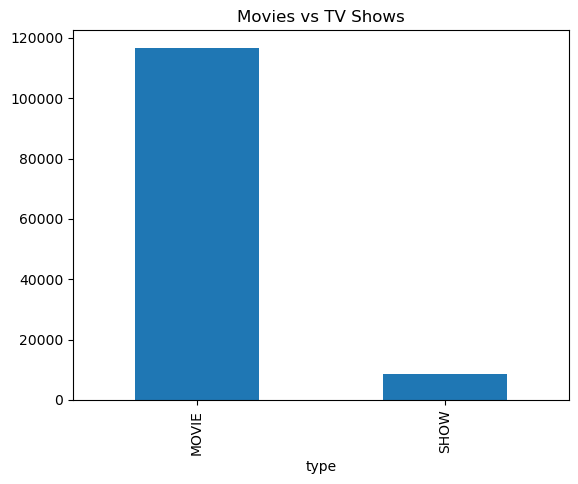

In [296]:
# Chart - 1 visualization code
df['type'].value_counts().plot(kind='bar')
plt.title("Movies vs TV Shows")
plt.show()

##### 1. Why did you pick the specific chart?

To compare distribution

##### 2. What is/are the insight(s) found from the chart?

Movies are more than TV shows

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Focus more on movies

#### Chart - 2 : Release Year Trend

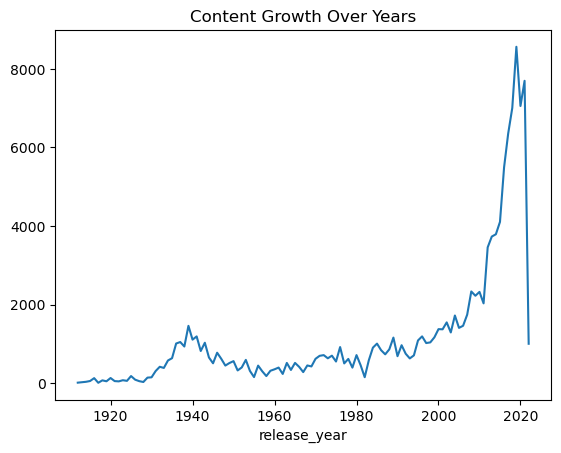

In [297]:
# Chart - 2 visualization code
df['release_year'].value_counts().sort_index().plot()
plt.title("Content Growth Over Years")
plt.show()

##### 1. Why did you pick the specific chart?

 Trend analysis

##### 2. What is/are the insight(s) found from the chart?

Content increased after 2010

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Platform growth is strong

#### Chart - 3

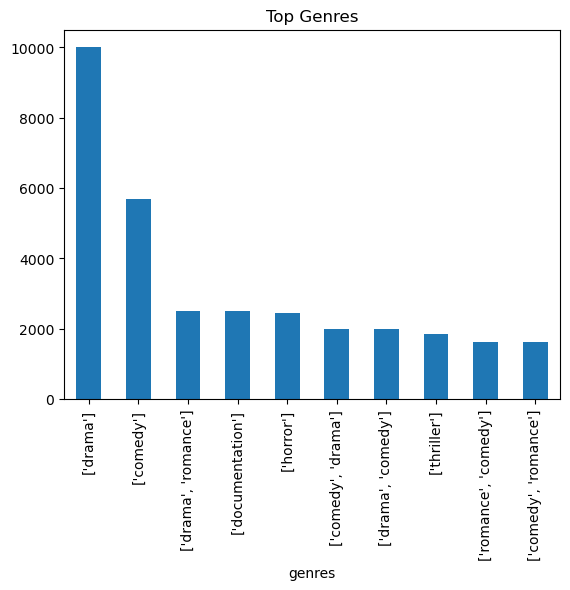

In [298]:
# Chart - 3 visualization code
df['genres'].value_counts().head(10).plot(kind='bar')
plt.title("Top Genres")
plt.show()

##### 1. Why did you pick the specific chart?

Popular categories

##### 2. What is/are the insight(s) found from the chart?

Drama & Comedy dominate

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Invest more in Drama and comedy

#### Chart - 4 :IMDb Score Distribution

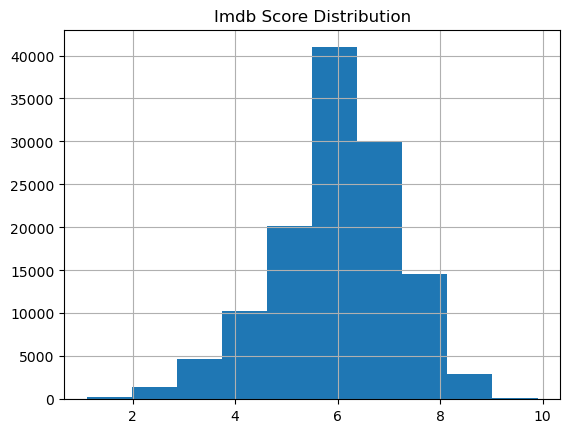

In [299]:
# Chart - 4 visualization code
df['imdb_score'].hist()
plt.title("Imdb Score Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

to Understand quality

##### 2. What is/are the insight(s) found from the chart?

Most ratings between 5–7

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Improve content quality

#### Chart - 5 : Runtime Distribution

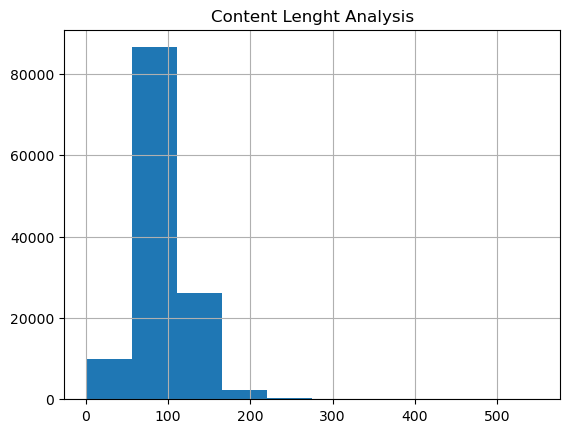

In [300]:
# Chart - 5 visualization code
df['runtime'].hist()
plt.title("Content Lenght Analysis")
plt.show()

##### 1. Why did you pick the specific chart?

Content length analysis

##### 2. What is/are the insight(s) found from the chart?

Most content ~90 mins

##### 3. Will the gained insights help creating a positive business impact?

Maintain optimal length

#### Chart - 6 : Top Production Countries

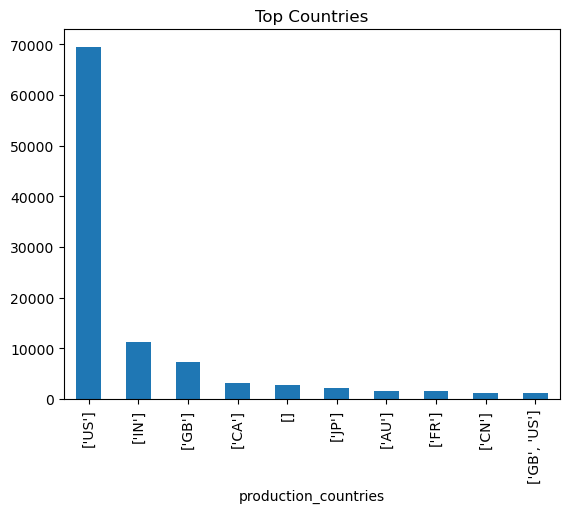

In [301]:
# Chart - 6 visualization code
df['production_countries'].value_counts().head(10).plot(kind='bar')
plt.title("Top Countries")
plt.show()

##### 1. Why did you pick the specific chart?

Market analysis

##### 2. What is/are the insight(s) found from the chart?

Few countries dominate

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Expand globally

#### Chart - 7 : Age Certification

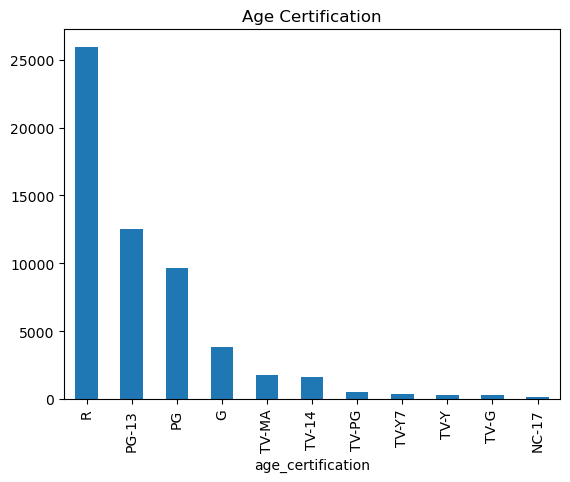

In [302]:
# Chart - 7 visualization code
df['age_certification'].value_counts().plot(kind='bar')
plt.title("Age Certification")
plt.show()

##### 1. Why did you pick the specific chart?

Audience segmentation

##### 2. What is/are the insight(s) found from the chart?

Most content is for adults

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Target diverse audiences

#### Chart - 8 : IMDb Votes Distribution

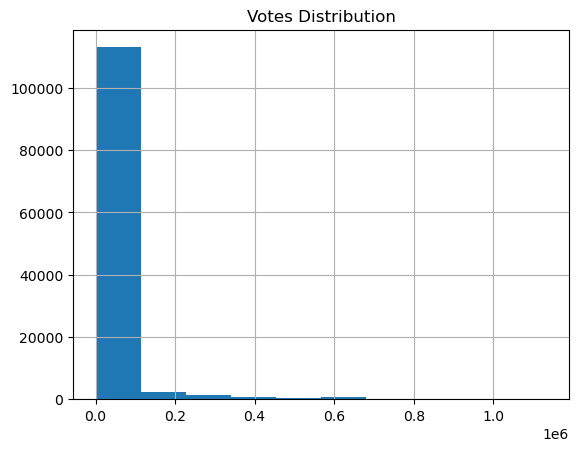

In [303]:
# Chart - 8 visualization code
df['imdb_votes'].hist()
plt.title("Votes Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

To find popular shows

##### 2. What is/are the insight(s) found from the chart?

Few shows get high votes

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Focus on engagement

#### Chart - 9 : Runtime vs IMDb Score

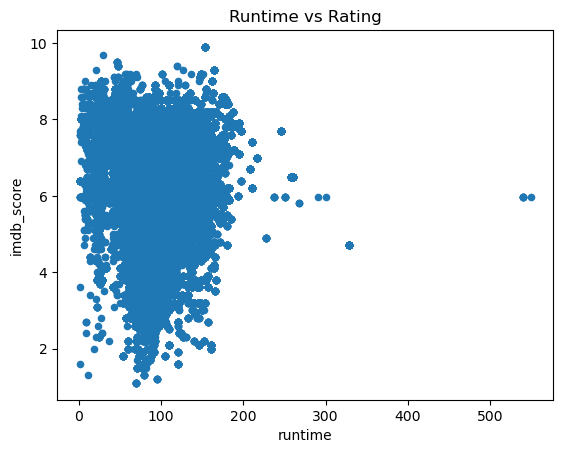

In [304]:
# Chart - 9 visualization code
df.plot.scatter(x='runtime', y='imdb_score')
plt.title("Runtime vs Rating")
plt.show()

##### 1. Why did you pick the specific chart?

to find Relationship

##### 2. What is/are the insight(s) found from the chart?

Weak correlation

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Runtime not critical

#### Chart - 10 : Movies vs Shows Over Time

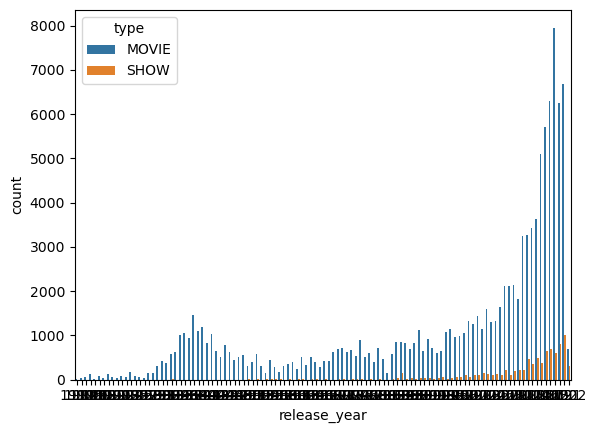

In [305]:
# Chart - 10 visualization code
import seaborn as sns
sns.countplot(x='release_year', hue='type', data=df)
plt.show()

##### 1. Why did you pick the specific chart?

Compare growth

##### 2. What is/are the insight(s) found from the chart?

Movies dominate yearly

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Strong movie strategy

#### Chart - 12 : Content Age Distribution

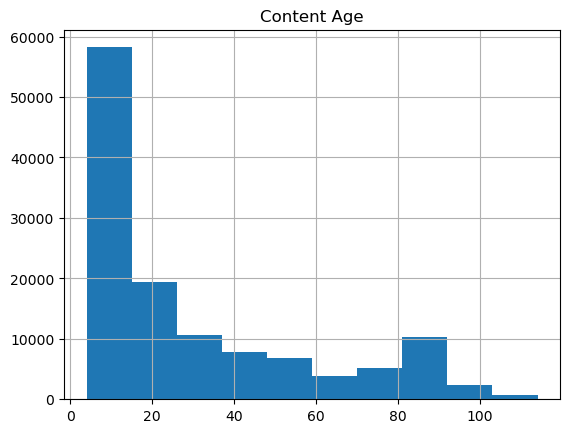

In [306]:
# Chart - 12 visualization code
df['content_age'] = 2026 - df['release_year']
df['content_age'].hist()
plt.title("Content Age")
plt.show()

##### 1. Why did you pick the specific chart?

Content freshness

##### 2. What is/are the insight(s) found from the chart?

Most content is recent

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Keep updating content

#### Chart - 14 - Correlation Heatmap

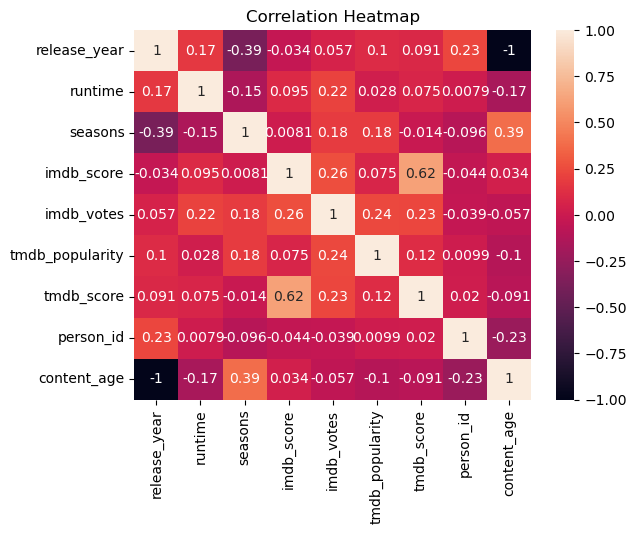

In [307]:
# Correlation Heatmap visualization code
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

Find relationships

##### 2. What is/are the insight(s) found from the chart?

Weak correlation between variables

#### Chart - 15 - Pair Plot

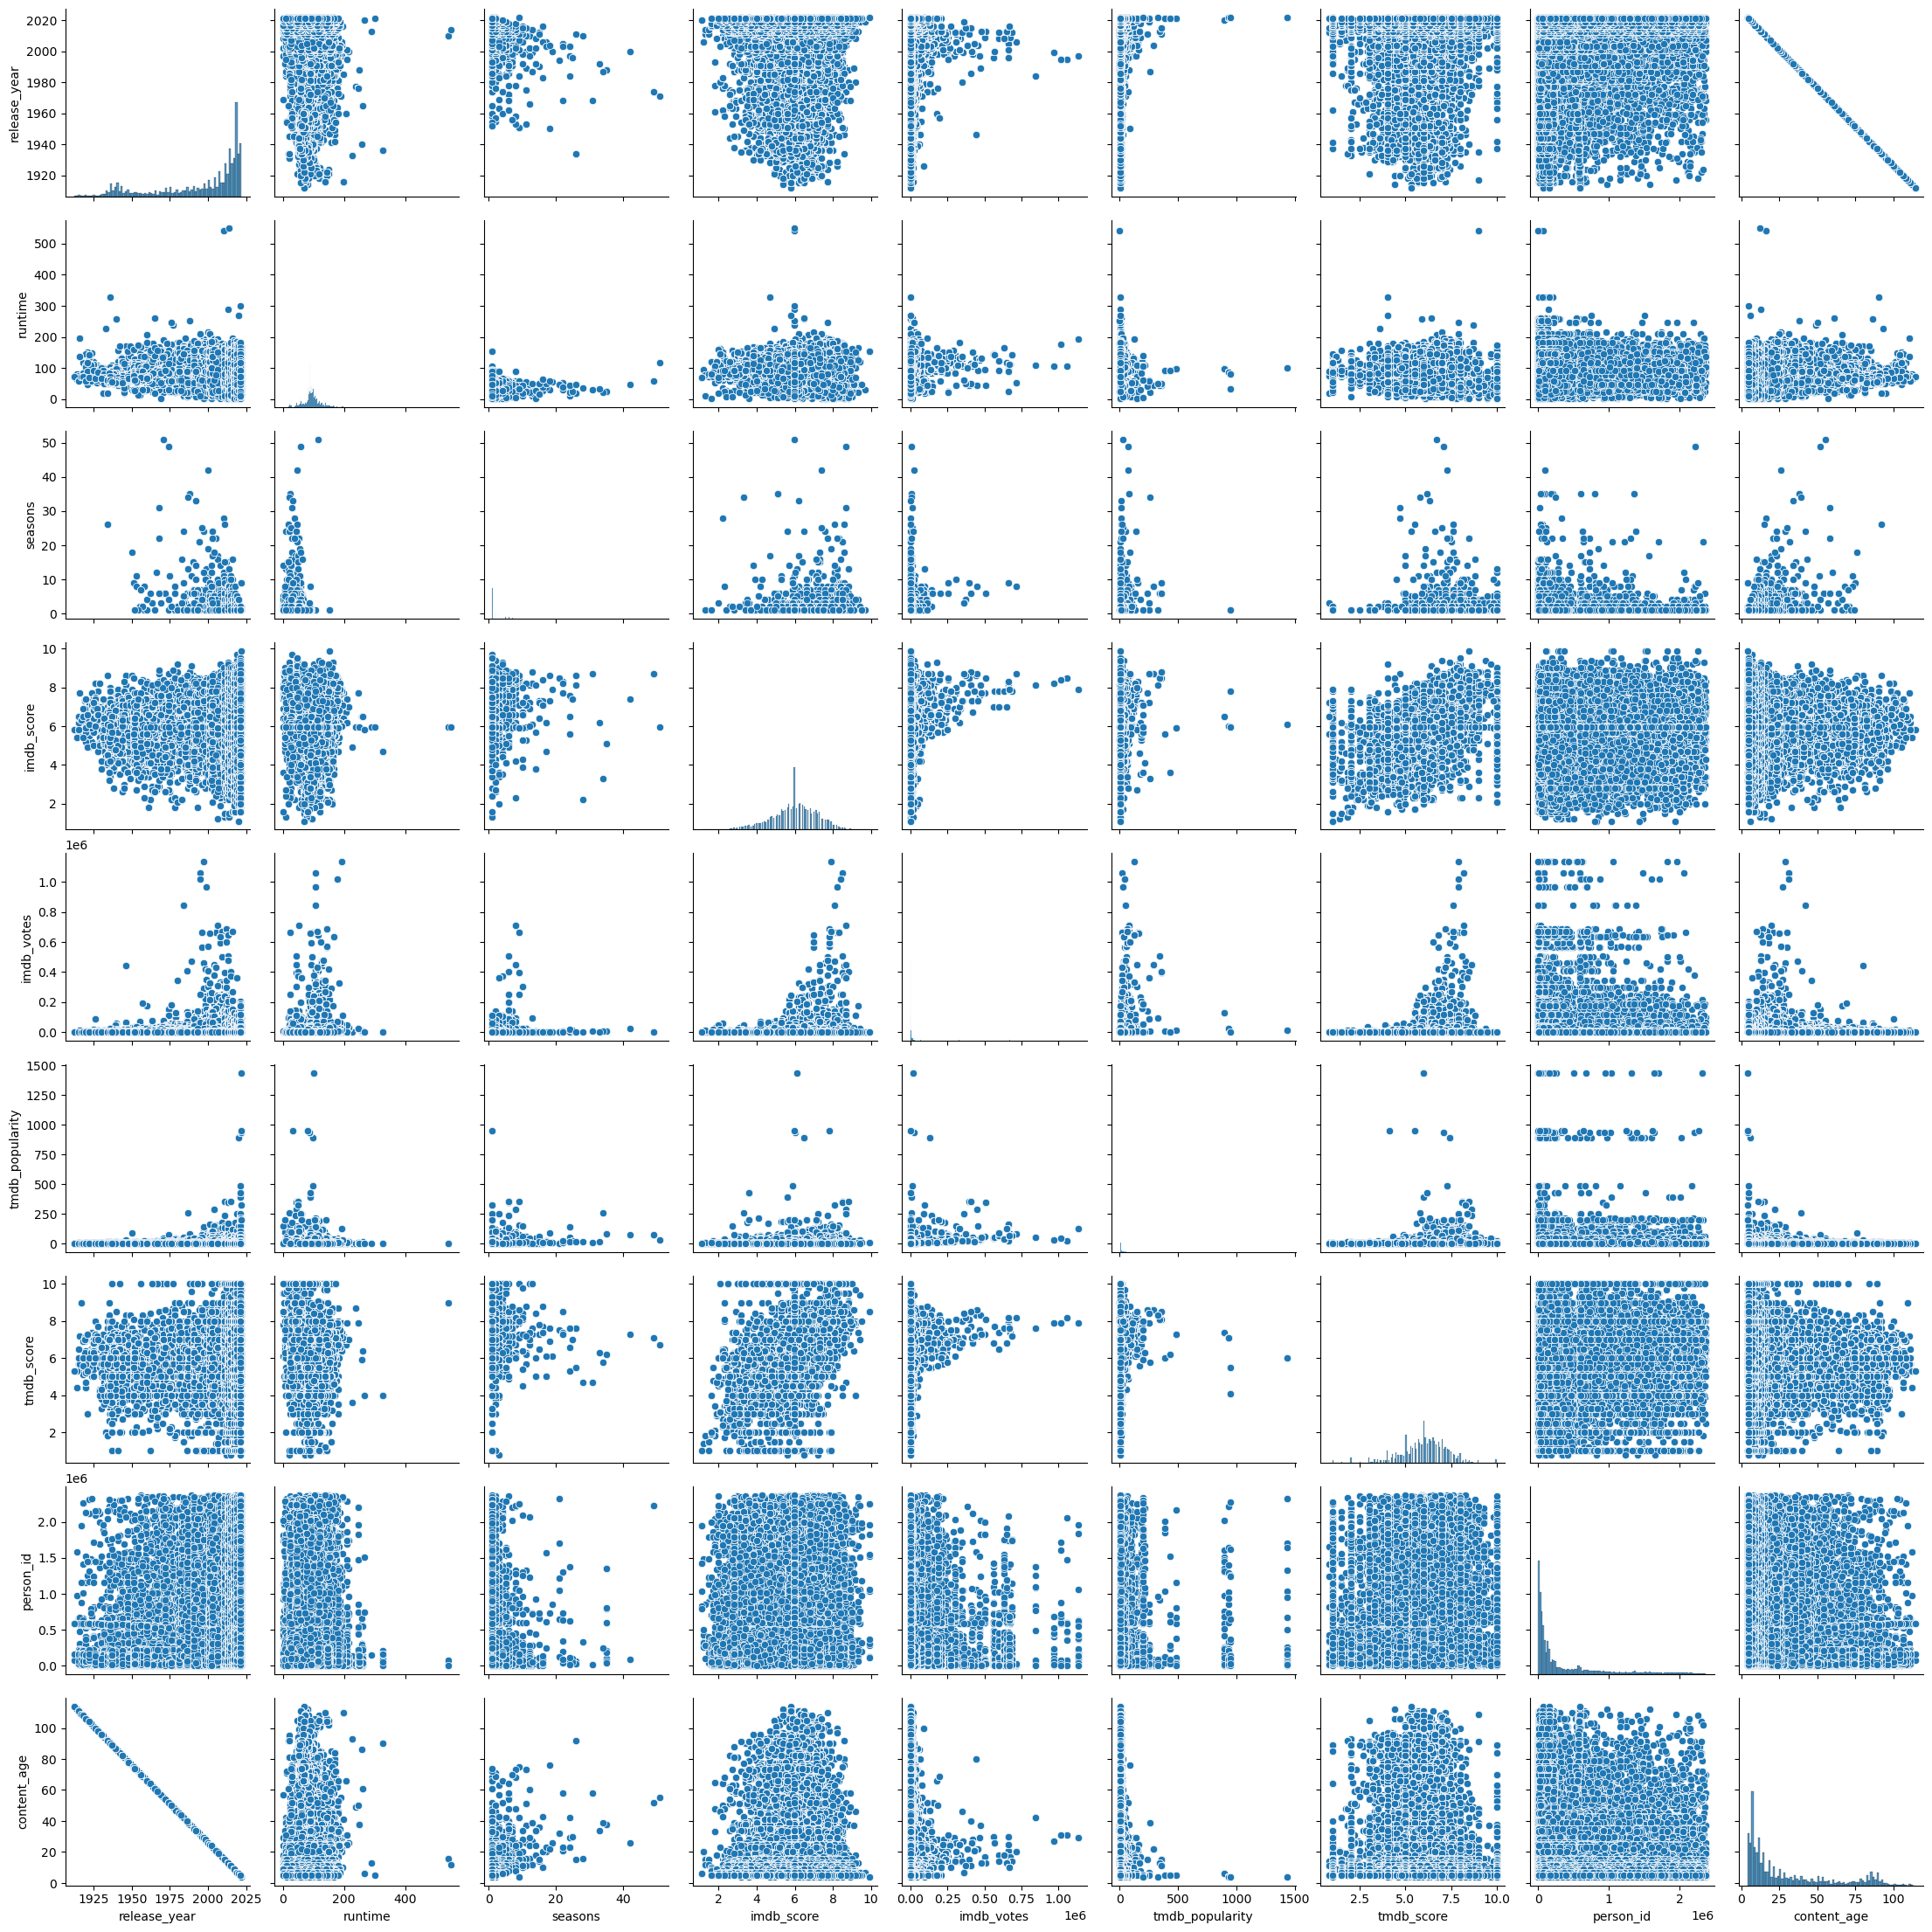

In [308]:
# Pair Plot visualization code
sns.pairplot(df.select_dtypes(include=['number']))
plt.show()

##### 1. Why did you pick the specific chart?

Multivariate analysis

##### 2. What is/are the insight(s) found from the chart?

No strong linear relationships

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

- Focus on High-Performing Genres: Invest more in popular genres such as Drama and Comedy, as they attract higher audience engagement.

- Increase Movie Production: Since movies dominate the platform, prioritizing movie content can maximize viewership.

- Improve Content Quality: Most content falls in the average rating range (5–7). Producing higher-quality content can improve ratings and user satisfaction.

- Leverage Popular Actors & Directors: Collaborating with well-known cast and crew can increase content popularity and reach.

- Expand Global Content: Increase production in diverse countries to attract a wider international audience.

- Optimize Content Duration: Focus on medium-length content (~90–120 minutes), which is most common and preferred.

- Regular Content Updates: Continuously add new and fresh content to maintain user interest and platform growth.

# **Conclusion**

By focusing on data-driven decisions such as genre preference, content quality, and audience trends, the client (Amazon Prime) can enhance user engagement, improve retention, and achieve sustainable business growth.